# L2: Gaussian Processes: theory and practice

---
**file name:** L2_fileB_gaussian_processes_intro.ipynb

Part of Lecture 2 - second notebook

**Instructor:** Alice Cicirello

**Generated for Training school scientific machine learning for digital twins**


**The first draft version of the notebook was generated using Anthropic's Claude**

**Date**: September 2026

**Last Modifications and checks made by Alice Cicirello on: 5/09/2026**

---

## Introduction

This notebook develops Gaussian Process (GP) regression *from the
probability up*. 

Every equation is paired with a small, runnable numerical experiment
so you can see the maths in action.

By the end you should be able to 

(i) explain what a GP
*is*, 

(ii) derive and implement the predictive equations, 

(iii) choose a covariance
kernel on physical grounds, 

(iv) identify its hyperparameters by maximising the
marginal likelihood.

---

## Learning objectives
1. Reframe regression as **inference over functions** rather than over parameters.
2. State the two Gaussian identities (**marginalisation** and **conditioning**) that make GPs tractable.
3. Write the GP **posterior predictive** equations and implement them in NumPy.
4. Understand the main **kernels** (RBF, Matérn, rational quadratic, periodic, linear), their
   smoothness/stationarity properties, and how to combine them.
5. Identify **hyperparameters** by maximising the **log marginal likelihood**, and understand
   why this embodies an automatic Occam's razor.

## Prerequisites
Linear algebra (matrix inverse, positive-definiteness, Cholesky), multivariate calculus,
and basic probability (Gaussian distribution, Bayes' rule). No prior exposure to GPs is assumed.

## Primary references
- C. E. Rasmussen & C. K. I. Williams, *Gaussian Processes for Machine Learning*, MIT Press, 2006 — **the** standard text, free at <http://gaussianprocess.org/gpml/>.
- D. J. C. MacKay, *Information Theory, Inference, and Learning Algorithms*, CUP, 2003, Ch. 45.
- C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006, §6.4.
- K. P. Murphy, *Probabilistic Machine Learning: Advanced Topics*, MIT Press, 2023, Ch. 18.
- M. Deisenroth, A. Faisal, C. Ong, *Mathematics for Machine Learning*, CUP, 2020 (Gaussian identities).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import cholesky, solve
from scipy.linalg import cho_factor, cho_solve

rng = np.random.default_rng(0)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Environment ready.")

Environment ready.


## 1. Regression as inference over *functions*

Suppose we observe data 

$\mathcal{D}=\{(\mathbf{x}_i, y_i)\}_{i=1}^n$ 

and believe

$y = f(\mathbf{x}) + \varepsilon$

with noise $\varepsilon\sim\mathcal{N}(0,\sigma_n^2)$.


Classical regression *parameterises* $f$ — e.g. $f(\mathbf{x})=\mathbf{w}^\top\boldsymbol{\phi}(\mathbf{x})$ —
and infers the weights $\mathbf{w}$.

In the **Bayesian linear model** we place a prior
$\mathbf{w}\sim\mathcal{N}(\mathbf{0},\Sigma_p)$ and obtain a Gaussian posterior over $\mathbf{w}$.

The key realisation: 

because $f$ is a *linear* function of the Gaussian $\mathbf{w}$, 

the
**prior over function values** $f(\mathbf{x})$ is itself Gaussian. 

Writing
$\phi_i=\boldsymbol{\phi}(\mathbf{x}_i)$,

$$
\mathbb{E}[f(\mathbf{x}_i)] = 0,\qquad
\operatorname{Cov}\!\big(f(\mathbf{x}_i),f(\mathbf{x}_j)\big)
= \boldsymbol{\phi}_i^\top \Sigma_p\, \boldsymbol{\phi}_j \;=:\; k(\mathbf{x}_i,\mathbf{x}_j).
$$

The weights have **vanished**, and we are left with the *covariance function* $k$.

A Gaussian Process takes this as the starting point: **forget the weights, model the covariance directly.**
This is the *weight-space $\to$ function-space* view (Rasmussen & Williams, Ch. 2).

The demo below draws posterior lines for a Bayesian linear model to build intuition for
"a distribution over functions".

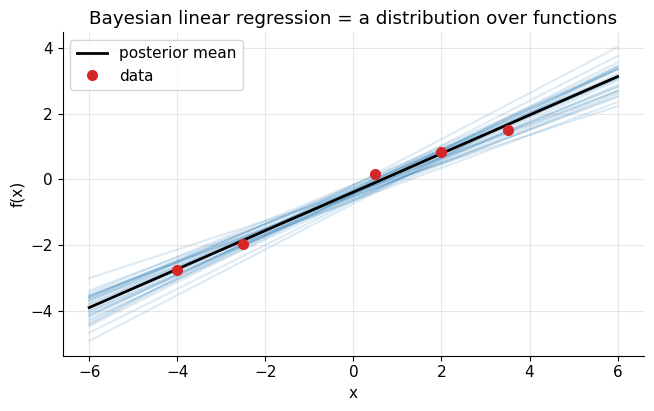

In [2]:
# Bayesian linear regression: posterior over straight lines f(x) = w0 + w1 x
x_train = np.array([-4., -2.5, 0.5, 2.0, 3.5])
y_train = 0.6 * x_train - 0.4 + rng.normal(0, 0.4, size=x_train.shape)

Phi = np.vstack([np.ones_like(x_train), x_train]).T   # design matrix, n x 2
sigma_n = 0.4
Sigma_p = np.eye(2) * 4.0                              # prior covariance on weights

A = Phi.T @ Phi / sigma_n**2 + np.linalg.inv(Sigma_p)
S_post = np.linalg.inv(A)                              # posterior covariance of w
m_post = S_post @ Phi.T @ y_train / sigma_n**2        # posterior mean of w

xs = np.linspace(-6, 6, 200)
Phis = np.vstack([np.ones_like(xs), xs]).T
W = rng.multivariate_normal(m_post, S_post, size=30)   # sample weight vectors
plt.figure()
for w in W:
    plt.plot(xs, Phis @ w, color="tab:blue", alpha=0.15)
plt.plot(xs, Phis @ m_post, "k", lw=2, label="posterior mean")
plt.plot(x_train, y_train, "o", color="tab:red", ms=7, label="data")
plt.title("Bayesian linear regression = a distribution over functions")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.legend(); plt.show()

## 2. The one distribution you must know: the multivariate Gaussian

A GP is *defined* so that any finite set of function values is jointly Gaussian, so the
whole method rests on two properties of the multivariate normal.

Let $\begin{bmatrix}\mathbf{a}\\ \mathbf{b}\end{bmatrix}
\sim \mathcal{N}\!\left(
\begin{bmatrix}\boldsymbol{\mu}_a\\ \boldsymbol{\mu}_b\end{bmatrix},
\begin{bmatrix} A & C\\ C^\top & B\end{bmatrix}\right)$.

**Marginalisation** — dropping variables just deletes rows/columns:
$$ \mathbf{a}\sim\mathcal{N}(\boldsymbol{\mu}_a,\,A). $$

**Conditioning** — observing $\mathbf{b}$ gives another Gaussian (Rasmussen & Williams, A.2):
$$
\mathbf{a}\mid\mathbf{b}\ \sim\ \mathcal{N}\!\Big(
\underbrace{\boldsymbol{\mu}_a + C B^{-1}(\mathbf{b}-\boldsymbol{\mu}_b)}_{\text{conditional mean}},\;
\underbrace{A - C B^{-1} C^\top}_{\text{conditional covariance}}\Big).
$$

These two lines *are* GP regression. Everything below is bookkeeping around them.

p(a | b=1.5) = N(mean=1.275, var=0.278)


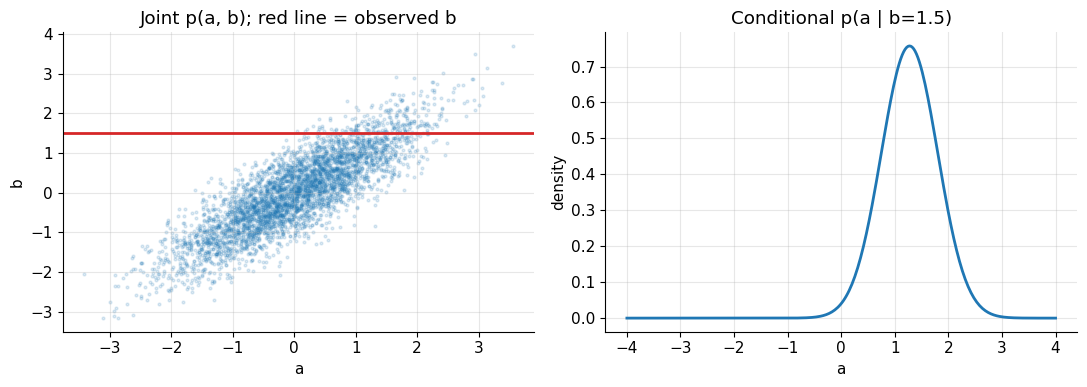

In [3]:
# Numerical illustration of conditioning on a correlated bivariate Gaussian
mu = np.array([0.0, 0.0])
rho = 0.85
Cov = np.array([[1.0, rho],[rho, 1.0]])
samples = rng.multivariate_normal(mu, Cov, size=4000)

b_obs = 1.5  # we observe the second coordinate b = 1.5
A_, B_, C_ = Cov[0,0], Cov[1,1], Cov[0,1]
cond_mean = mu[0] + C_/B_ * (b_obs - mu[1])
cond_var  = A_ - C_/B_ * C_
print(f"p(a | b={b_obs}) = N(mean={cond_mean:.3f}, var={cond_var:.3f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(samples[:,0], samples[:,1], s=4, alpha=0.15)
ax[0].axhline(b_obs, color="tab:red", lw=2)
ax[0].set_title("Joint p(a, b); red line = observed b"); ax[0].set_xlabel("a"); ax[0].set_ylabel("b")
aa = np.linspace(-4, 4, 300)
ax[1].plot(aa, np.exp(-(aa-cond_mean)**2/(2*cond_var))/np.sqrt(2*np.pi*cond_var), lw=2)
ax[1].set_title("Conditional p(a | b=1.5)"); ax[1].set_xlabel("a"); ax[1].set_ylabel("density")
plt.tight_layout(); plt.show()

## 3. Definition of a Gaussian Process

> **Definition (Rasmussen & Williams, 2006).** A *Gaussian Process* is a collection of random
> variables, any finite number of which have a joint Gaussian distribution.

A GP is fully specified by a **mean function** and a **covariance (kernel) function**:
$$
m(\mathbf{x}) = \mathbb{E}[f(\mathbf{x})],\qquad
k(\mathbf{x},\mathbf{x}') = \mathbb{E}\big[(f(\mathbf{x})-m(\mathbf{x}))(f(\mathbf{x}')-m(\mathbf{x}'))\big],
$$
written
$$
f(\mathbf{x}) \sim \mathcal{GP}\big(m(\mathbf{x}),\, k(\mathbf{x},\mathbf{x}')\big).
$$

**Note**: We usually take $m(\mathbf{x})=0$ (after centring the data).

The GP is then a **prior over
functions**: to draw a sample we pick a finite grid $X_\star$, build the covariance matrix
$K(X_\star,X_\star)$ with entries $K_{ij}=k(\mathbf{x}_i,\mathbf{x}_j)$, and sample
$\mathbf{f}_\star\sim\mathcal{N}(\mathbf{0},K)$. 

The kernel must be a valid covariance, i.e. it
must produce a **symmetric positive semi-definite** $K$ for every finite input set.

Below we use the **squared-exponential** (RBF) kernel
$$
k(x,x') = \sigma_f^2 \exp\!\left(-\frac{(x-x')^2}{2\ell^2}\right)
$$
and draw functions from the prior. Note we never chose weights — we sampled *functions* directly.

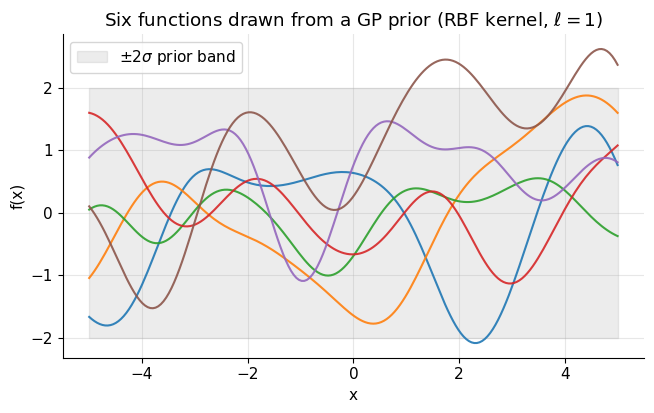

In [4]:
def rbf_kernel(X1, X2, lengthscale=1.0, sigma_f=1.0):
    X1 = np.atleast_2d(X1).reshape(-1, 1)
    X2 = np.atleast_2d(X2).reshape(-1, 1)
    sqdist = (X1 - X2.T)**2
    return sigma_f**2 * np.exp(-0.5 * sqdist / lengthscale**2)

Xs = np.linspace(-5, 5, 200)
K = rbf_kernel(Xs, Xs, lengthscale=1.0, sigma_f=1.0)
K += 1e-9 * np.eye(len(Xs))                 # jitter for numerical PSD-ness
L = cholesky(K)
prior_samples = (L @ rng.standard_normal((len(Xs), 6)))

plt.figure()
plt.plot(Xs, prior_samples, alpha=0.9)
plt.fill_between(Xs, -2, 2, color="grey", alpha=0.15, label=r"$\pm 2\sigma$ prior band")
plt.title("Six functions drawn from a GP prior (RBF kernel, $\\ell=1$)")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.legend(); plt.show()

## 4. GP regression: the predictive equations

Now condition the prior on data. Let $X=\{\mathbf{x}_i\}$ be training inputs with noisy targets
$\mathbf{y}$, and $X_\star$ the test inputs at which we want predictions $\mathbf{f}_\star$.
Under the noise model $y_i = f(\mathbf{x}_i)+\varepsilon_i$, $\varepsilon_i\sim\mathcal{N}(0,\sigma_n^2)$,
the joint prior over observed targets and test values is
$$
\begin{bmatrix}\mathbf{y}\\ \mathbf{f}_\star\end{bmatrix}
\sim \mathcal{N}\!\left(\mathbf{0},\;
\begin{bmatrix} K(X,X)+\sigma_n^2 I & K(X,X_\star)\\
K(X_\star,X) & K(X_\star,X_\star)\end{bmatrix}\right).
$$

Applying the **conditioning identity** from §2 gives the GP posterior
(Rasmussen & Williams, Eqs. 2.23–2.24):
$$
\boxed{\;
\begin{aligned}
\bar{\mathbf{f}}_\star &= K(X_\star,X)\,\big[K(X,X)+\sigma_n^2 I\big]^{-1}\mathbf{y},\\[4pt]
\operatorname{cov}(\mathbf{f}_\star) &= K(X_\star,X_\star) -
K(X_\star,X)\,\big[K(X,X)+\sigma_n^2 I\big]^{-1}K(X,X_\star).
\end{aligned}\;}
$$

Two things are worth pausing on:
- The predictive **mean is linear in $\mathbf{y}$** — it is a weighted sum of kernel functions
  "anchored" at the training points, $\bar f_\star(\mathbf{x})=\sum_i \alpha_i\, k(\mathbf{x},\mathbf{x}_i)$.
- The predictive **variance does not depend on $\mathbf{y}$** at all — only on *where* you sampled.
  Uncertainty shrinks near data and grows away from it, which is exactly what an engineer wants
  from a surrogate model.

**Numerical issues!** Never form the inverse. Use the Cholesky factor
$L L^\top = K+\sigma_n^2 I$ and solve triangular systems (Rasmussen & Williams, Algorithm 2.1).
This is $\mathcal{O}(n^3)$ once, then $\mathcal{O}(n)$ / $\mathcal{O}(n^2)$ per test point.

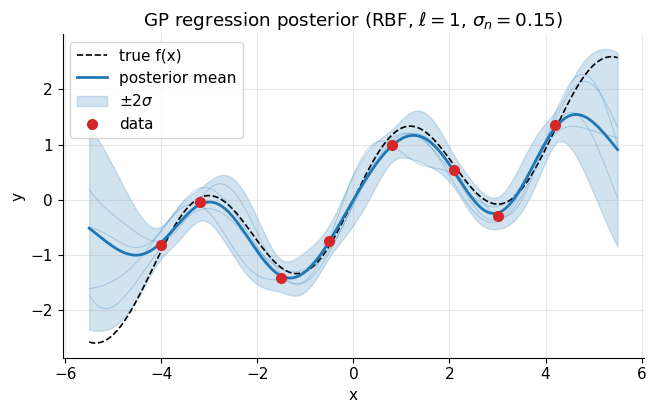

In [5]:
def gp_posterior(X_train, y_train, X_test, kernel, sigma_n=1e-2, jitter=1e-10):
    # Posterior mean and covariance via the stable Cholesky route (RW Alg. 2.1)
    K   = kernel(X_train, X_train) + (sigma_n**2 + jitter) * np.eye(len(X_train))
    Ks  = kernel(X_train, X_test)
    Kss = kernel(X_test,  X_test)
    L   = cholesky(K)                      # K = L L^T
    alpha = solve(L.T, solve(L, y_train))  # alpha = K^{-1} y
    mean  = Ks.T @ alpha                    # predictive mean (Eq. 2.23)
    v     = solve(L, Ks)                    # v = L^{-1} Ks
    cov   = Kss - v.T @ v                   # predictive covariance (Eq. 2.24)
    return mean, cov

# A noisy 1-D data set from an unknown ground truth
f_true = lambda x: np.sin(1.5*x) + 0.3*x
Xtr = np.array([-4.0, -3.2, -1.5, -0.5, 0.8, 2.1, 3.0, 4.2])
ytr = f_true(Xtr) + rng.normal(0, 0.15, size=Xtr.shape)
Xte = np.linspace(-5.5, 5.5, 300)

kern = lambda a, b: rbf_kernel(a, b, lengthscale=1.0, sigma_f=1.0)
mu, cov = gp_posterior(Xtr, ytr, Xte, kern, sigma_n=0.15)
sd = np.sqrt(np.clip(np.diag(cov), 0, None))

plt.figure()
plt.plot(Xte, f_true(Xte), "k--", lw=1.2, label="true f(x)")
plt.plot(Xte, mu, "tab:blue", lw=2, label="posterior mean")
plt.fill_between(Xte, mu-2*sd, mu+2*sd, color="tab:blue", alpha=0.2, label=r"$\pm 2\sigma$")
# a few posterior function samples
Lp = cholesky(cov + 1e-9*np.eye(len(Xte)))
for s in (Lp @ rng.standard_normal((len(Xte), 4))).T:
    plt.plot(Xte, mu + s, color="tab:blue", alpha=0.25, lw=0.8)
plt.plot(Xtr, ytr, "o", color="tab:red", ms=7, label="data")
plt.title("GP regression posterior (RBF, $\\ell=1$, $\\sigma_n=0.15$)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper left"); plt.show()

## 5. Kernels: encoding your prior beliefs about $f$

The kernel is where **domain knowledge enters**. It controls:

smoothness, 

characteristic length
scales, 

amplitude, 

periodicity

and trends. 

A function $k$ is a valid kernel iff it yields a
symmetric positive semi-definite Gram matrix for every finite input set (Mercer's condition).

### 5.1 A catalogue (with the properties that matter)

| Kernel | $k(r)$, $r=\lVert x-x'\rVert$ | Sample-path smoothness | Typical use |
|---|---|---|---|
| **Squared exponential / RBF** | $\sigma_f^2\exp(-r^2/2\ell^2)$ | infinitely differentiable (very smooth) | smooth interpolation; default |
| **Matérn $\nu=3/2$** | $\sigma_f^2\,(1+\tfrac{\sqrt3 r}{\ell})\exp(-\tfrac{\sqrt3 r}{\ell})$ | once differentiable | physical signals, mildly rough |
| **Matérn $\nu=5/2$** | $\sigma_f^2\,(1+\tfrac{\sqrt5 r}{\ell}+\tfrac{5r^2}{3\ell^2})\exp(-\tfrac{\sqrt5 r}{\ell})$ | twice differentiable | good general default (e.g. Bayesian optimisation) |
| **Rational quadratic** | $\sigma_f^2\,(1+\tfrac{r^2}{2\alpha\ell^2})^{-\alpha}$ | smooth; mixture of length scales | data with multiple scales |
| **Periodic (Exp-Sine²)** | $\sigma_f^2\exp\!\big(-\tfrac{2}{\ell^2}\sin^2(\pi r/p)\big)$ | smooth, period $p$ | seasonal / rotational signals |
| **Linear (dot-product)** | $\sigma_f^2\,(x\!\cdot\!x')$ | — (non-stationary) | trends; recovers Bayesian linear regression |

**Stationarity.** RBF, Matérn, RQ and periodic depend only on the *distance* $r$ — they are
*stationary* (translation-invariant). The linear kernel does not, and encodes a global trend.

**The Matérn family and physical smoothness.** The parameter $\nu$ controls mean-square
differentiability: sample paths are $\lceil\nu\rceil-1$ times differentiable. The RBF is the
$\nu\to\infty$ limit and is often *too* smooth for real measurements; $\nu=5/2$ or $3/2$ are
usually more honest choices for engineering data (Stein, 1999, *Interpolation of Spatial Data*).

### 5.2 Automatic Relevance Determination (ARD)

In $d$ dimensions, give each input its own length scale:
$$
k(\mathbf{x},\mathbf{x}') = \sigma_f^2\exp\!\Big(-\tfrac12\textstyle\sum_{q=1}^{d}\frac{(x_q-x'_q)^2}{\ell_q^2}\Big).
$$
A large learned $\ell_q$ means input $q$ barely affects the output — so ARD performs
soft **feature selection** (MacKay, 1998; Neal, 1996).

### 5.3 Composing kernels

Kernels are closed under addition and multiplication, which lets you build structured priors:
- **Sum** $k_1+k_2$ = "$f$ is a sum of contributions" (e.g. long-term trend **+** short-term wiggle).
- **Product** $k_1\times k_2$ = "both properties must hold" (e.g. periodic **×** RBF = *locally* periodic).

This compositional grammar (Duvenaud et al., 2013) is how the famous Mauna Loa CO$_2$ model is built.

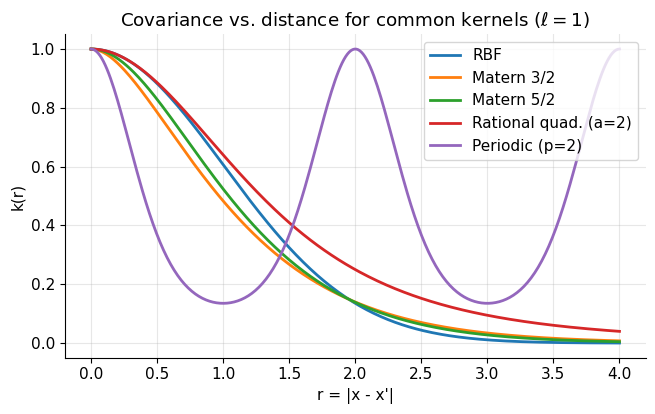

In [6]:
# --- Visualise the kernels as a function of distance r ---
r = np.linspace(0, 4, 300)
ell = 1.0
k_rbf   = np.exp(-0.5*r**2/ell**2)
k_m32   = (1 + np.sqrt(3)*r/ell)*np.exp(-np.sqrt(3)*r/ell)
k_m52   = (1 + np.sqrt(5)*r/ell + 5*r**2/(3*ell**2))*np.exp(-np.sqrt(5)*r/ell)
k_rq    = (1 + r**2/(2*2.0*ell**2))**(-2.0)          # alpha = 2
k_per   = np.exp(-2*np.sin(np.pi*r/2.0)**2/ell**2)   # period p = 2

plt.figure()
for k, lab in [(k_rbf,"RBF"),(k_m32,"Matern 3/2"),(k_m52,"Matern 5/2"),
               (k_rq,"Rational quad. (a=2)"),(k_per,"Periodic (p=2)")]:
    plt.plot(r, k, lw=2, label=lab)
plt.title("Covariance vs. distance for common kernels ($\\ell=1$)")
plt.xlabel("r = |x - x'|"); plt.ylabel("k(r)"); plt.legend(); plt.show()

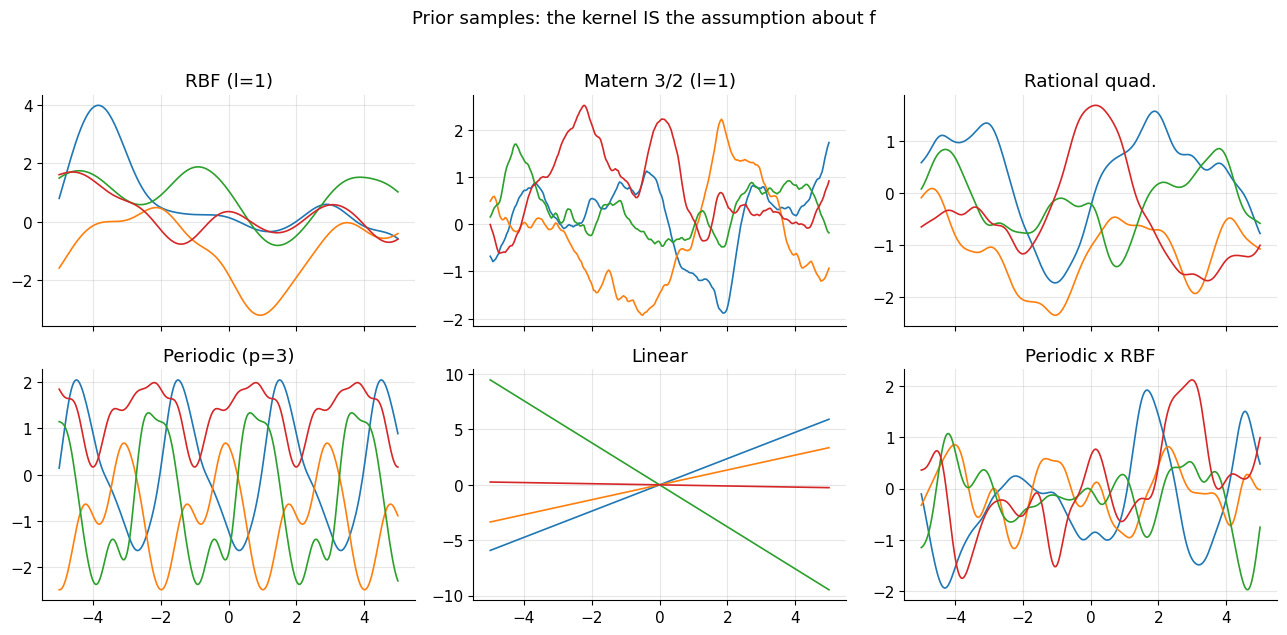

In [7]:
# --- Prior samples reveal the character each kernel imposes ---
from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic,
                                              ExpSineSquared, DotProduct)
Xg = np.linspace(-5, 5, 250).reshape(-1, 1)
kernels = {
    "RBF (l=1)":            1.0*RBF(1.0),
    "Matern 3/2 (l=1)":     1.0*Matern(1.0, nu=1.5),
    "Rational quad.":       1.0*RationalQuadratic(length_scale=1.0, alpha=0.5),
    "Periodic (p=3)":       1.0*ExpSineSquared(length_scale=1.0, periodicity=3.0),
    "Linear":               0.5*DotProduct(sigma_0=0.0),
    "Periodic x RBF":       1.0*ExpSineSquared(1.0, 3.0)*RBF(3.0),
}
fig, axes = plt.subplots(2, 3, figsize=(13, 6.2), sharex=True)
for ax, (name, kobj) in zip(axes.ravel(), kernels.items()):
    Kg = kobj(Xg) + 1e-8*np.eye(len(Xg))
    Lg = cholesky(Kg)
    ax.plot(Xg, Lg @ rng.standard_normal((len(Xg), 4)), lw=1.2)
    ax.set_title(name); ax.grid(alpha=0.3)
fig.suptitle("Prior samples: the kernel IS the assumption about f", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

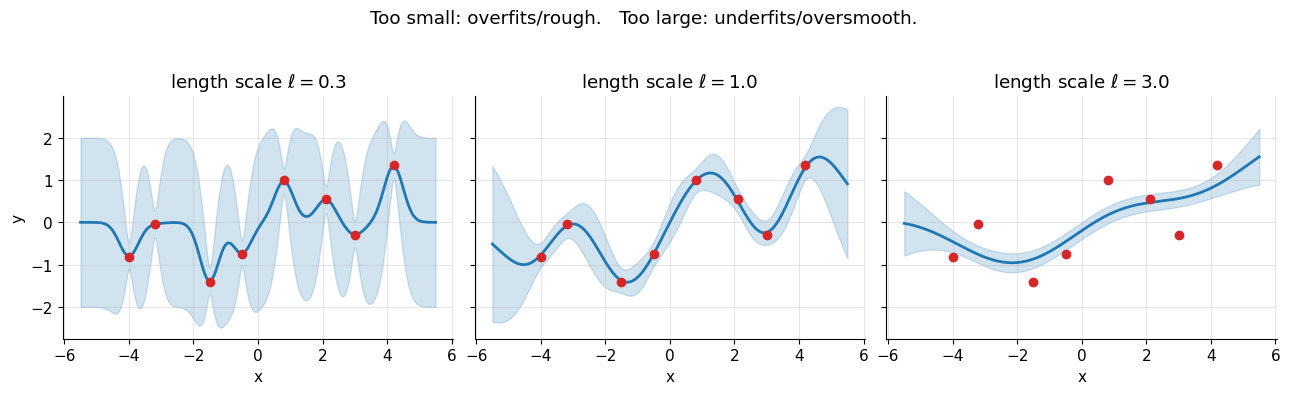

In [8]:
# --- The length scale controls how fast the function can vary ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, l in zip(axes, [0.3, 1.0, 3.0]):
    kern_l = lambda a, b, l=l: rbf_kernel(a, b, lengthscale=l, sigma_f=1.0)
    m, c = gp_posterior(Xtr, ytr, Xte, kern_l, sigma_n=0.15)
    s = np.sqrt(np.clip(np.diag(c), 0, None))
    ax.plot(Xte, m, "tab:blue", lw=2)
    ax.fill_between(Xte, m-2*s, m+2*s, color="tab:blue", alpha=0.2)
    ax.plot(Xtr, ytr, "o", color="tab:red", ms=6)
    ax.set_title(f"length scale $\\ell = {l}$"); ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.suptitle("Too small: overfits/rough.   Too large: underfits/oversmooth.", y=1.03)
plt.tight_layout(); plt.show()

## 6. Hyperparameter identification

The kernel has free **hyperparameters** $\boldsymbol{\theta}$ :

signal variance $\sigma_f^2$,

length scale(s) $\ell$, 

plus the noise variance $\sigma_n^2$. 

The previous figure shows the
prediction depends *strongly* on them, so how do we choose them **from the data**?

### 6.1 The marginal likelihood (evidence)

Because the GP prior is Gaussian and the noise is Gaussian, we can **integrate out the latent
function analytically**. The probability of the observed data given only the hyperparameters is
$$
p(\mathbf{y}\mid X,\boldsymbol{\theta})
= \int p(\mathbf{y}\mid \mathbf{f})\,p(\mathbf{f}\mid X,\boldsymbol{\theta})\,d\mathbf{f}
= \mathcal{N}\big(\mathbf{y}\,\big|\,\mathbf{0},\, K_{\boldsymbol{\theta}}+\sigma_n^2 I\big).
$$

Its logarithm — the **log marginal likelihood (LML)** — is the objective we optimise
(Rasmussen & Williams, Eq. 2.30). With $K_y = K_{\boldsymbol{\theta}}+\sigma_n^2 I$:
$$
\boxed{\;\log p(\mathbf{y}\mid X,\boldsymbol{\theta})
= \underbrace{-\tfrac12\,\mathbf{y}^\top K_y^{-1}\mathbf{y}}_{\text{data fit}}
\;\underbrace{-\tfrac12\log\lvert K_y\rvert}_{\text{complexity penalty}}
\;-\;\tfrac{n}{2}\log 2\pi.\;}
$$

**Automatic Occam's razor.** The two terms pull in opposite directions.

The *data-fit* term
rewards models that explain $\mathbf{y}$ well (favouring small length scales, flexible fits).


The *complexity* term $-\tfrac12\log|K_y|$ penalises overly flexible priors. Their balance is
selected *automatically* — no separate validation set, no hand-tuned regularisation weight
(MacKay, 2003, Ch. 28; Rasmussen & Williams, §5.4).

### 6.2 Optimisation

We maximise the LML by gradient ascent. The gradients are available in closed form
(Rasmussen & Williams, Eq. 5.9): with $\boldsymbol{\alpha}=K_y^{-1}\mathbf{y}$,
$$
\frac{\partial}{\partial\theta_j}\log p(\mathbf{y}\mid X,\boldsymbol{\theta})
= \tfrac12\,\operatorname{tr}\!\Big[(\boldsymbol{\alpha}\boldsymbol{\alpha}^\top - K_y^{-1})
\frac{\partial K_y}{\partial\theta_j}\Big].
$$
The LML is generally **non-convex**, so we use several random restarts and keep the best.

### 6.3 Alternatives
- **Cross-validation** (leave-one-out has a closed form for GPs; Rasmussen & Williams, §5.4.2) —
  more robust to model misspecification but costlier.
- **MAP / priors on $\boldsymbol{\theta}$** — add $\log p(\boldsymbol{\theta})$ to keep length scales sane.
- **Fully Bayesian** — place a prior on $\boldsymbol{\theta}$ and marginalise with MCMC/HMC
  (e.g. via `PyMC`/`GPyTorch`) when point estimates are risky (small $n$).

First, let's *see* the objective surface.

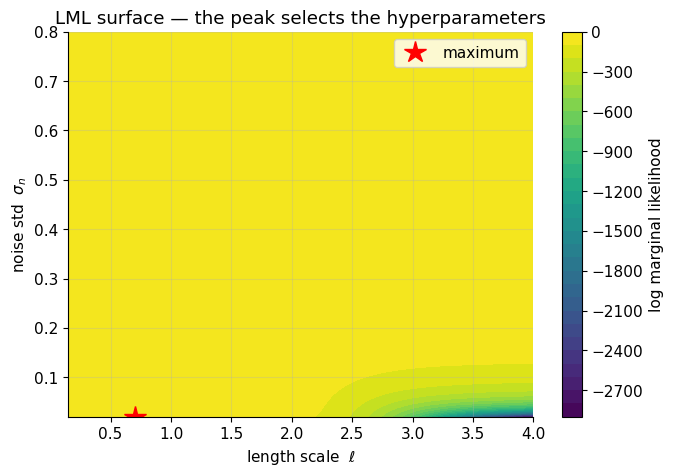

Grid-optimal: lengthscale=0.700, sigma_n=0.020


In [9]:
def log_marginal_likelihood(X, y, lengthscale, sigma_f, sigma_n):
    K = rbf_kernel(X, X, lengthscale, sigma_f) + sigma_n**2 * np.eye(len(X))
    try:
        c, low = cho_factor(K)
    except np.linalg.LinAlgError:
        return -np.inf
    alpha = cho_solve((c, low), y)
    logdet = 2.0 * np.sum(np.log(np.diag(c)))
    return -0.5*y @ alpha - 0.5*logdet - 0.5*len(X)*np.log(2*np.pi)

ls_grid = np.linspace(0.15, 4.0, 120)
sn_grid = np.linspace(0.02, 0.8, 120)
LML = np.array([[log_marginal_likelihood(Xtr, ytr, l, 1.0, s)
                 for l in ls_grid] for s in sn_grid])

i, j = np.unravel_index(np.argmax(LML), LML.shape)
plt.figure(figsize=(7.5, 5))
cs = plt.contourf(ls_grid, sn_grid, LML, levels=30, cmap="viridis")
plt.colorbar(cs, label="log marginal likelihood")
plt.plot(ls_grid[j], sn_grid[i], "r*", ms=16, label="maximum")
plt.xlabel("length scale  $\\ell$"); plt.ylabel("noise std  $\\sigma_n$")
plt.title("LML surface — the peak selects the hyperparameters")
plt.legend(); plt.show()
print(f"Grid-optimal: lengthscale={ls_grid[j]:.3f}, sigma_n={sn_grid[i]:.3f}")

Optimised kernel: 1.02**2 * RBF(length_scale=0.632) + WhiteKernel(noise_level=0.001)
Log marginal likelihood at optimum: -11.217


C:\Users\ac685\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


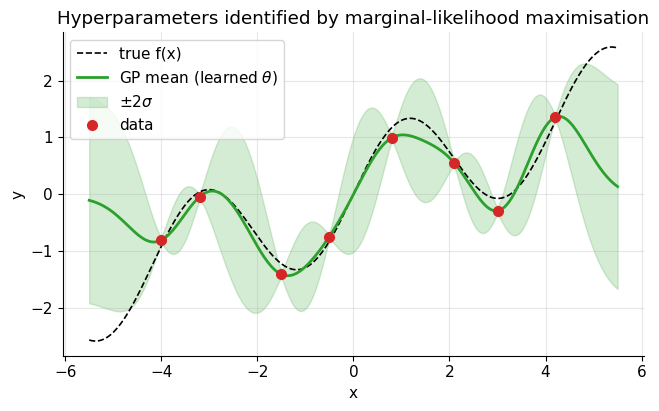

In [10]:
# --- Let scikit-learn optimise the hyperparameters by maximising the LML ---
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, WhiteKernel

kernel = C(1.0, (1e-2, 1e2)) * RBF(1.0, (1e-1, 1e1)) + WhiteKernel(0.1, (1e-3, 1e0))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=8,
                               normalize_y=True, random_state=0)
gpr.fit(Xtr.reshape(-1,1), ytr)

print("Optimised kernel:", gpr.kernel_)
print(f"Log marginal likelihood at optimum: {gpr.log_marginal_likelihood_value_:.3f}")

mu_sk, sd_sk = gpr.predict(Xte.reshape(-1,1), return_std=True)
plt.figure()
plt.plot(Xte, f_true(Xte), "k--", lw=1.2, label="true f(x)")
plt.plot(Xte, mu_sk, "tab:green", lw=2, label="GP mean (learned $\\theta$)")
plt.fill_between(Xte, mu_sk-2*sd_sk, mu_sk+2*sd_sk, color="tab:green", alpha=0.2, label=r"$\pm 2\sigma$")
plt.plot(Xtr, ytr, "o", color="tab:red", ms=7, label="data")
plt.title("Hyperparameters identified by marginal-likelihood maximisation")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper left"); plt.show()

**Reading the output.** `scikit-learn` reports the fitted kernel, e.g.
`0.9**2 * RBF(length_scale=1.2) + WhiteKernel(noise_level=0.02)`. The three learned numbers are
exactly $\sigma_f$, $\ell$ and $\sigma_n^2$ — recovered *from data alone* by maximising the LML.
Because that surface is non-convex we set `n_restarts_optimizer=8`; always use several restarts
in practice, and inspect whether the length scale has collided with a bound (a sign of
mis-specification or too little data).

## 6.4 Worked example: ARD as automatic feature selection (2-D)

Length scales are not just a smoothness knob — in several dimensions they tell you **which inputs
matter**. 

Here we build a target that depends strongly on $x_1$ and is (almost) independent of
$x_2$, then fit an **ARD RBF** kernel with a *separate* length scale per input:
$$
k(\mathbf{x},\mathbf{x}') = \sigma_f^2\exp\!\Big(-\tfrac12\big[\tfrac{(x_1-x_1')^2}{\ell_1^2}
+\tfrac{(x_2-x_2')^2}{\ell_2^2}\big]\Big).
$$

We expect the marginal likelihood to *drive $\ell_2$ large* (the input is irrelevant, so the
function should be flat along it), while $\ell_1$ stays $\mathcal{O}(1)$. The learned relevances
$1/\ell_q$ then rank the inputs (MacKay, 1998; Neal, 1996).

In [11]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, WhiteKernel

# Ground truth: depends on x1, essentially NOT on x2
def f2d(X):
    return np.sin(2.0*X[:, 0]) + 0.5*X[:, 0]

n = 90
X2 = rng.uniform(-3, 3, size=(n, 2))
y2 = f2d(X2) + rng.normal(0, 0.1, n)

kernel2 = (C(1.0, (1e-2, 1e2)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-1, 1e2))
           + WhiteKernel(0.1, (1e-3, 1e0)))
gpr2 = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=8,
                                normalize_y=True, random_state=0)
gpr2.fit(X2, y2)

ell = np.asarray(gpr2.kernel_.k1.k2.length_scale)   # the RBF length scales [l1, l2]
print("Optimised kernel:", gpr2.kernel_)
print(f"Learned length scales:  l1 = {ell[0]:.2f}   l2 = {ell[1]:.2f}")
print(f"Relevance (1/l):        x1 = {1/ell[0]:.3f}  x2 = {1/ell[1]:.3f}")
print("-> x2's huge length scale = the GP has learned it is irrelevant.")

Optimised kernel: 1.73**2 * RBF(length_scale=[1.1, 100]) + WhiteKernel(noise_level=0.0112)
Learned length scales:  l1 = 1.10   l2 = 100.00
Relevance (1/l):        x1 = 0.909  x2 = 0.010
-> x2's huge length scale = the GP has learned it is irrelevant.


C:\Users\ac685\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


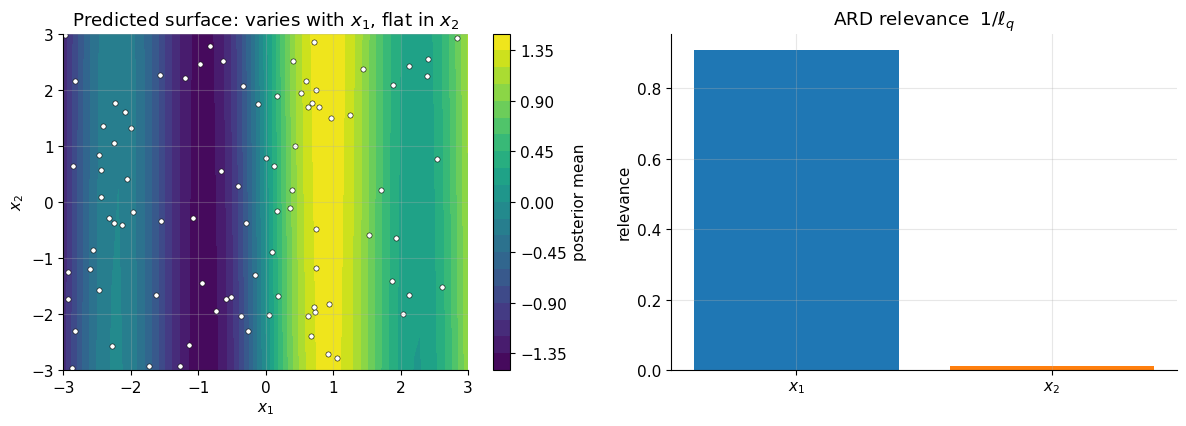

In [12]:
# Left: learned posterior-mean surface (flat along x2).  Right: relevance ranking.
g = np.linspace(-3, 3, 60)
G1, G2 = np.meshgrid(g, g)
grid = np.column_stack([G1.ravel(), G2.ravel()])
mu_grid = gpr2.predict(grid).reshape(G1.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
cs = ax[0].contourf(G1, G2, mu_grid, levels=25, cmap="viridis")
ax[0].scatter(X2[:, 0], X2[:, 1], c="white", s=14, edgecolor="k", linewidth=0.4)
fig.colorbar(cs, ax=ax[0], label="posterior mean")
ax[0].set_title("Predicted surface: varies with $x_1$, flat in $x_2$")
ax[0].set_xlabel("$x_1$"); ax[0].set_ylabel("$x_2$")

ax[1].bar(["$x_1$", "$x_2$"], 1/ell, color=["tab:blue", "tab:orange"])
ax[1].set_title("ARD relevance  $1/\\ell_q$"); ax[1].set_ylabel("relevance")
plt.tight_layout(); plt.show()

## 6.5 Worked example: building a structured kernel (Mauna Loa CO$_2$)

The famous demonstration in Rasmussen & Williams (§5.4.3) models atmospheric CO$_2$ by **adding
kernels that each capture one physical component** of the signal. We reproduce it on a
reproducible synthetic series with the same structure (rising trend + annual cycle + irregular
medium-scale variation + noise), then let the GP **extrapolate several years into the future** —
where a bare RBF would simply revert to the mean but this composed kernel carries the seasonal
structure forward.

$$
k = \underbrace{k_{\text{RBF}}^{\text{long}}}_{\text{smooth trend}}
  + \underbrace{k_{\text{RBF}} \cdot k_{\text{periodic}}}_{\text{decaying annual cycle}}
  + \underbrace{k_{\text{RQ}}}_{\text{medium irregularities}}
  + \underbrace{k_{\text{white}}}_{\text{noise}} .
$$
The **product** periodic $\times$ RBF is the key trick: multiplying a periodic kernel by a
long-length-scale RBF makes the cycle *locally* periodic — its amplitude may slowly drift rather
than repeat forever (Duvenaud et al., 2013).

In [13]:
from sklearn.gaussian_process.kernels import ExpSineSquared, RationalQuadratic

# --- Reproducible "Mauna Loa-like" monthly series (time in years) ---
t = np.linspace(0, 40, 40*12)
trend    = 0.012*t**2 + 1.2*t + 315.0            # accelerating rise
seasonal = 3.0*np.sin(2*np.pi*t) + 1.0*np.sin(4*np.pi*t + 0.5)
irregular = 0.6*np.sin(2*np.pi*t/6.0)             # ~6-year wobble
co2 = trend + seasonal + irregular + rng.normal(0, 0.35, t.shape)

split = 33.0                                       # train on <33 yr, forecast the rest
tr = t < split
Xc, yc = t[tr].reshape(-1, 1), co2[tr]

k_trend    = C(50.0, (1e0, 1e4)) * RBF(length_scale=40.0, length_scale_bounds=(10, 1e3))
k_seasonal = (C(2.0, (1e-1, 1e2))
              * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
              * RBF(length_scale=60.0, length_scale_bounds=(10, 1e3)))
k_medium   = C(0.5, (1e-2, 1e2)) * RationalQuadratic(length_scale=1.0, alpha=1.0)
k_noise    = WhiteKernel(0.3, (1e-3, 1e1))
kernel_ml  = k_trend + k_seasonal + k_medium + k_noise

gpr_ml = GaussianProcessRegressor(kernel=kernel_ml, n_restarts_optimizer=2,
                                  normalize_y=True, random_state=0)
gpr_ml.fit(Xc, yc)
print("Learned kernel:\n", gpr_ml.kernel_)

Learned kernel:
 3.96**2 * RBF(length_scale=57.6) + 0.538**2 * ExpSineSquared(length_scale=2.93, periodicity=1) * RBF(length_scale=1e+03) + 0.1**2 * RationalQuadratic(alpha=1e+05, length_scale=2.43) + WhiteKernel(noise_level=0.001)


C:\Users\ac685\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\ac685\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\ac685\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\ac685\anaconda3\Lib\site-packages\sklearn\gaussian_pr

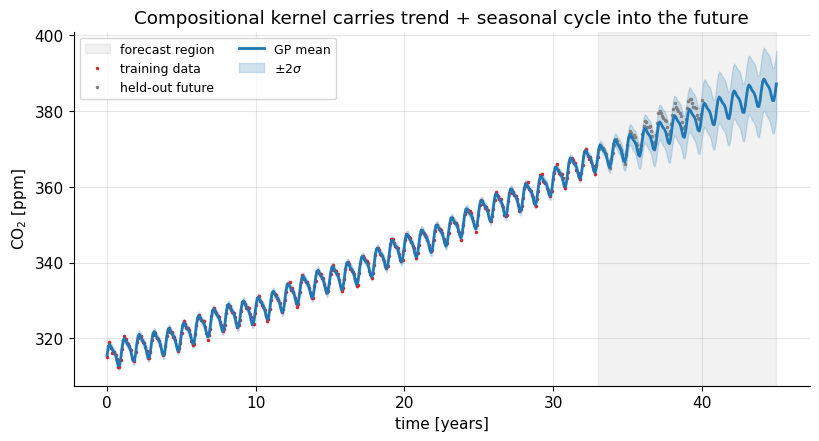

In [14]:
tt = np.linspace(0, 45, 45*12).reshape(-1, 1)      # predict 5 years past the data
mu_ml, sd_ml = gpr_ml.predict(tt, return_std=True)

plt.figure(figsize=(9.5, 4.6))
plt.axvspan(split, 45, color="grey", alpha=0.10, label="forecast region")
plt.plot(t[tr], co2[tr], ".", ms=3, color="tab:red", label="training data")
plt.plot(t[~tr], co2[~tr], ".", ms=3, color="0.5", label="held-out future")
plt.plot(tt, mu_ml, "tab:blue", lw=2, label="GP mean")
plt.fill_between(tt.ravel(), mu_ml-2*sd_ml, mu_ml+2*sd_ml, color="tab:blue", alpha=0.2, label=r"$\pm 2\sigma$")
plt.title("Compositional kernel carries trend + seasonal cycle into the future")
plt.xlabel("time [years]"); plt.ylabel("CO$_2$ [ppm]")
plt.legend(loc="upper left", ncol=2, fontsize=9); plt.show()

**What to notice.** 

The forecast (grey region) keeps oscillating with the correct annual period and
tracks the accelerating trend, with the credible band widening as we move away from the data. 

Read
off the fitted kernel: the long RBF length scale sets the trend smoothness, the `ExpSineSquared`
period is pinned to 1 year, and the `WhiteKernel` recovers the measurement noise — each learned
number maps to a physical component you put in by hand. 

That interpretability is a large part of why
GPs are prized in engineering and the geosciences.

## 7. Practical considerations & limitations

- **Cost.** The Cholesky factorisation is $\mathcal{O}(n^3)$ time and $\mathcal{O}(n^2)$ memory.
  Exact GPs are comfortable to $n\sim$ few thousand. Beyond that use **sparse / inducing-point**
  approximations (Snelson & Ghahramani, 2006; Titsias, 2009) or **SVGP** in `GPyTorch`/`GPflow`.
- **Numerical stability.** Always add a small **jitter** ($10^{-6}\!-\!10^{-9}$) to the diagonal,
  standardise inputs/outputs, and factor via Cholesky rather than inverting.
- **Mean function.** A zero mean assumes the data are centred; for extrapolation you may want an
  explicit parametric mean (GP on the residual), otherwise predictions revert to $0$ far from data.
- **Model checking.** Inspect the learned length scale, the noise level, and standardised
  residuals; compare candidate kernels by their optimised LML (a rough Bayesian model-selection
  score) or by held-out log-predictive density.
- **When GPs shine in engineering.** Small/medium data with a need for **calibrated uncertainty**:
  surrogate modelling of expensive simulations, Bayesian optimisation, sensor-fusion, spatial
  interpolation (kriging is a GP), and system identification.

## 8. Summary

1. A GP is a **prior over functions**, defined by a mean and a kernel; any finite set of function
   values is jointly Gaussian.
2. Regression is just **Gaussian conditioning** — the posterior predictive mean and covariance
   follow in two lines and are implemented stably with a Cholesky factorisation.
3. The **kernel encodes your assumptions** (smoothness, length scale, periodicity, trends); Matérn
   $5/2$ is a sensible default for physical data, and kernels compose by $+$ and $\times$.
4. **Hyperparameters are identified by maximising the log marginal likelihood**, which balances data
   fit against model complexity — an automatic Occam's razor — with cross-validation and fully
   Bayesian treatments as alternatives.

### Exercises
1. Swap the RBF for `Matern(nu=1.5)` in §4 and compare the roughness of the posterior samples.
2. Build the Mauna Loa-style kernel `long RBF + periodic×RBF + rational quadratic + white` and fit it.
3. In §6.1 add a log-normal prior on $\ell$ and maximise the *posterior* (MAP) instead of the LML.
4. Generate 2-D data and use an ARD RBF (`RBF([1,1])`); interpret the two learned length scales.

### References
- C. E. Rasmussen & C. K. I. Williams, *Gaussian Processes for Machine Learning*, MIT Press, 2006. Free: <http://gaussianprocess.org/gpml/>
- D. J. C. MacKay, *Information Theory, Inference, and Learning Algorithms*, CUP, 2003, Ch. 45.
- C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006, §6.4.
- K. P. Murphy, *Probabilistic Machine Learning: Advanced Topics*, MIT Press, 2023, Ch. 18.
- M. L. Stein, *Interpolation of Spatial Data: Some Theory for Kriging*, Springer, 1999 (Matérn smoothness).
- R. M. Neal, *Bayesian Learning for Neural Networks*, Springer, 1996 (ARD, GP limit).
- D. Duvenaud, J. Lloyd, R. Grosse, J. Tenenbaum, Z. Ghahramani, "Structure Discovery in Nonparametric Regression through Compositional Kernel Search", *ICML*, 2013.
- E. Snelson & Z. Ghahramani, "Sparse Gaussian Processes using Pseudo-inputs", *NeurIPS*, 2006; M. Titsias, "Variational Learning of Inducing Variables in Sparse GPs", *AISTATS*, 2009.
- Software: `scikit-learn` (`sklearn.gaussian_process`), `GPy`, `GPflow`, `GPyTorch`, `PyMC`.